In [2]:
import sys
import os

# Get the absolute path to the .src directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

In [11]:
from src.data import SPGDataset
import numpy as np
dataset = SPGDataset(root="../data/spg")

def normalize_absolute_coords(points):
	centroid = np.mean(points, axis=0)
	points -= centroid
	furthest_distance = np.max(np.sqrt(np.sum(abs(points)**2,axis=-1)))
	points /= furthest_distance

	return points

In [3]:
import torch

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon

def draw_sketch(pos, strokes, ax):
    prop_cycle = plt.rcParams['axes.prop_cycle']
    default_colors = prop_cycle.by_key()['color']


    for stroke in np.unique(strokes):
        stroke_points = pos[stroke == strokes]
        ax.plot(stroke_points[:, 0], -stroke_points[:, 1], color=default_colors[stroke])
        
        delta = np.diff(stroke_points, axis=0)
        delta = np.append(delta, delta[-1, None], axis=0)
        delta = delta / np.sqrt((delta ** 2).sum(axis=1))[:, None]

        for i in range(len(delta)):
            angle = np.degrees(np.arctan2(delta[i, 0], -delta[i, 1]))
            
            # Create a triangle marker using RegularPolygon (triangle = numVertices=3)
            triangle = RegularPolygon(
                (stroke_points[i, 0], -stroke_points[i, 1]),             # (x, y) position
                numVertices=3,            # Triangle
                radius=0.02,              # Size of marker
                orientation=np.radians(angle),  # Rotation in radians
                color=default_colors[stroke]
            )
            ax.add_patch(triangle)

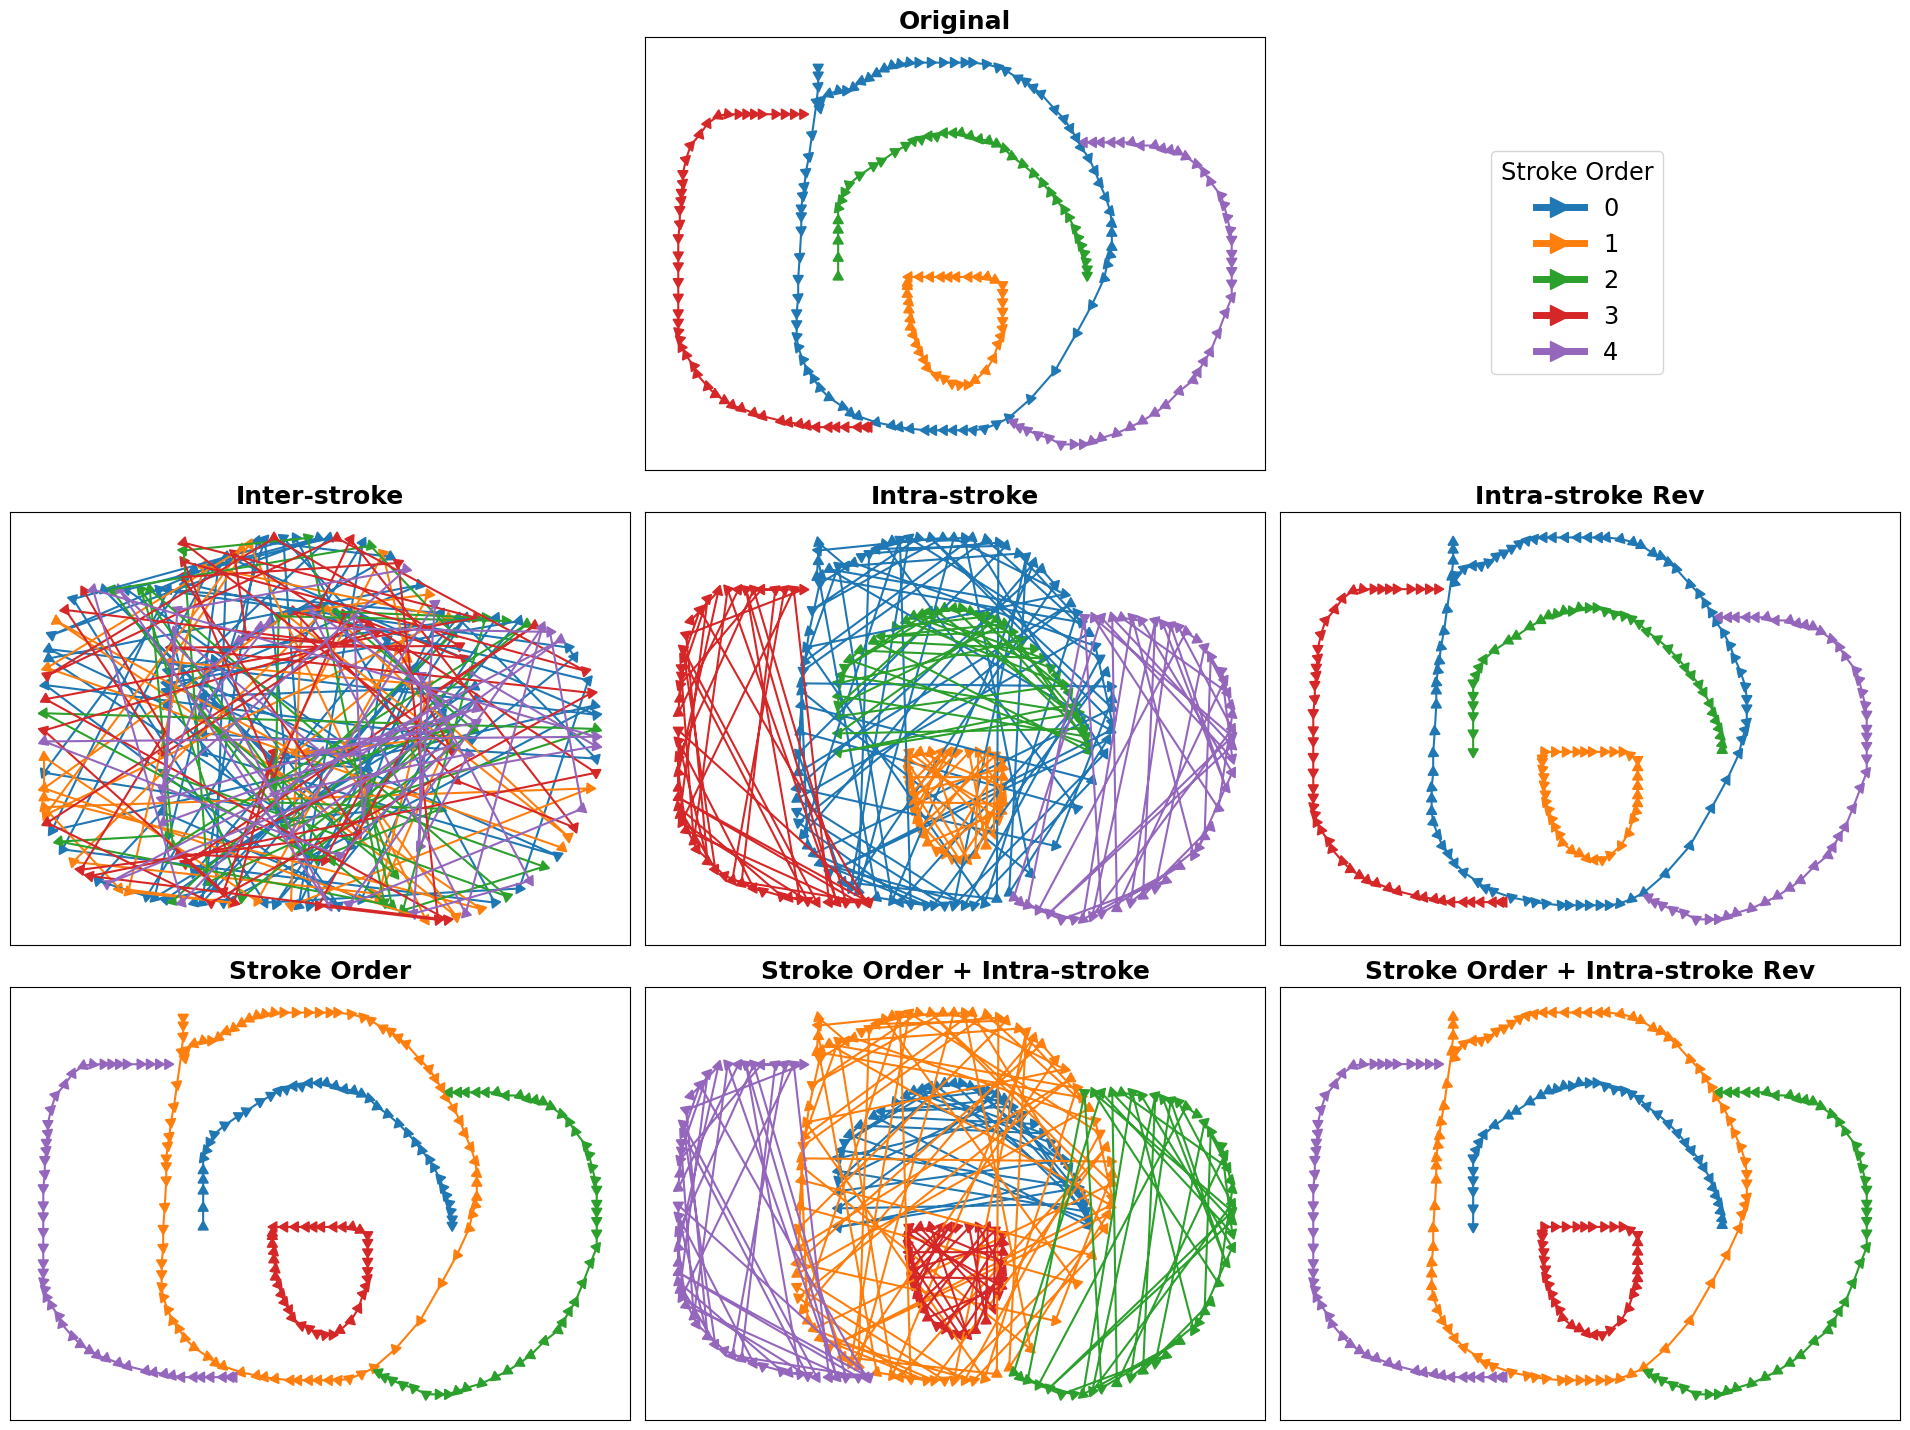

In [5]:
pos = dataset[67]['pos_absolute']
labels = dataset[67]['label']
strokes = dataset[67]['stroke_id']

fig, axis = plt.subplots(3, 3, figsize=(6.4 * 3,  3 * 4.8))

prop_cycle = plt.rcParams['axes.prop_cycle']
default_colors = prop_cycle.by_key()['color']


axis = axis.flatten()

axis[1].set_title("Original", fontweight="bold", size=18)
draw_sketch(pos, strokes, axis[1])    


axis[3].set_title("Inter-stroke", fontweight="bold", size=18)
inter_stroke_pos = pos[torch.randperm(pos.shape[0])]
draw_sketch(inter_stroke_pos, strokes, axis[3])

intra_stroke_pos = pos.copy()
for stroke in np.unique(strokes):
    intra_stroke_pos[stroke == strokes] = pos[stroke == strokes][torch.randperm((stroke == strokes).sum())]

axis[4].set_title("Intra-stroke", fontweight="bold", size=18)
draw_sketch(intra_stroke_pos, strokes, axis[4])

unique_groups = np.unique(strokes)
permuted_strokes = unique_groups[torch.randperm(len(unique_groups))]
mapping = {old.item(): new.item() for old, new in zip(unique_groups, permuted_strokes)}
permuted_strokes = torch.tensor([mapping[g.item()] for g in strokes])
original_index = torch.arange(len(permuted_strokes))
composite_index = permuted_strokes * len(permuted_strokes) + original_index


sort_idx = torch.argsort(composite_index)
permuted_strokes = permuted_strokes[sort_idx]

axis[5].set_title("Intra-stroke Rev", fontweight="bold", size=18)
rev_pos = pos.copy()
for stroke in np.unique(strokes)[torch.randperm(len(unique_groups))[:len(unique_groups)//2 + 1]]:
    rev_pos[stroke == strokes] = pos[stroke == strokes][::-1] 
draw_sketch(rev_pos, strokes, axis[5])

axis[6].set_title("Stroke Order", fontweight="bold", size=18)
draw_sketch(pos[sort_idx], permuted_strokes, axis[6])



axis[7].set_title("Stroke Order + Intra-stroke", fontweight="bold", size=18)
draw_sketch(intra_stroke_pos[sort_idx], permuted_strokes, axis[7])

axis[8].set_title("Stroke Order + Intra-stroke Rev", fontweight="bold", size=18)
draw_sketch(rev_pos[sort_idx], permuted_strokes, axis[8])

axis[0].axis("off")
axis[2].axis("off")
#fig.suptitle("Sketch Order Peturbations")
ax = plt.gca()
for i in range(len(axis)):
    axis[i].set_xticks([])
    axis[i].set_yticks([])


for stroke in np.unique(strokes):
    ax.plot([], [], marker=">", markersize=15, linewidth=5, color=default_colors[stroke], label=int(stroke))
handles, labels = ax.get_legend_handles_labels()
fig.legend( handles, labels, title="Stroke Order", loc='upper right', ncol=1, bbox_to_anchor=(0.875, 0.9), fontsize='xx-large', title_fontsize='xx-large')
plt.tight_layout()
fig.savefig("../perturbations.svg")


In [5]:
strokes = dataset[67]['stroke_id']
pen_state = dataset[67]['pen_state']
stroke_pos = dataset[67]['stroke_pos']
unique_groups = np.unique(strokes)
permuted_strokes = unique_groups[torch.randperm(len(unique_groups))]
mapping = {old.item(): new.item() for old, new in zip(unique_groups, permuted_strokes)}
permuted_strokes = torch.tensor([mapping[g.item()] for g in strokes])
original_index = torch.arange(len(permuted_strokes))
composite_index = permuted_strokes * len(permuted_strokes) + original_index


sort_idx = torch.argsort(composite_index)

strokes = permuted_strokes[sort_idx]
stroke_pos = stroke_pos[sort_idx]
pen_state[-1] = [0., 1., 0.]
pen_state = pen_state[sort_idx]
pen_state[-1] = [0., 0., 1.]

for stroke, stroke_len in zip(*np.unique(strokes, return_counts=True)):
    print(stroke_len, pen_state[stroke == strokes][-1, :])


47 [0. 1. 0.]
51 [0. 1. 0.]
41 [0. 1. 0.]
38 [0. 1. 0.]
86 [0. 0. 1.]


In [6]:
from src.data import SPGDataset, QuickDrawDataset, PerturbationsConfig

data = []
data.append((QuickDrawDataset("../data/quickdraw/", perturbations=PerturbationsConfig(False, False, False, False))[100], "Original"))
data.append((QuickDrawDataset("../data/quickdraw/", perturbations=PerturbationsConfig(True, False, False, False))[100], "Inter-Stroke"))
data.append((QuickDrawDataset("../data/quickdraw/", perturbations=PerturbationsConfig(False, True, False, False))[100], "Intra-Stroke"))
data.append((QuickDrawDataset("../data/quickdraw/", perturbations=PerturbationsConfig(False, False, True, False))[100], "Intra-Stroke Rev"))
data.append((QuickDrawDataset("../data/quickdraw/", perturbations=PerturbationsConfig(False, False, False, True))[100], "Stroke Order"))
data.append((QuickDrawDataset("../data/quickdraw/", perturbations=PerturbationsConfig(False, True, False, True))[100], "Stroke Order + Intra-Stroke"))
data.append((QuickDrawDataset("../data/quickdraw/", perturbations=PerturbationsConfig(False, False, True, True))[100], "Stroke Order + Intra-Stroke Rev"))

In [7]:
def normalize_absolute_coords(points):
	centroid = np.mean(points, axis=0)
	points -= centroid
	furthest_distance = np.max(np.sqrt(np.sum(abs(points)**2,axis=-1)))
	points /= furthest_distance

	return points

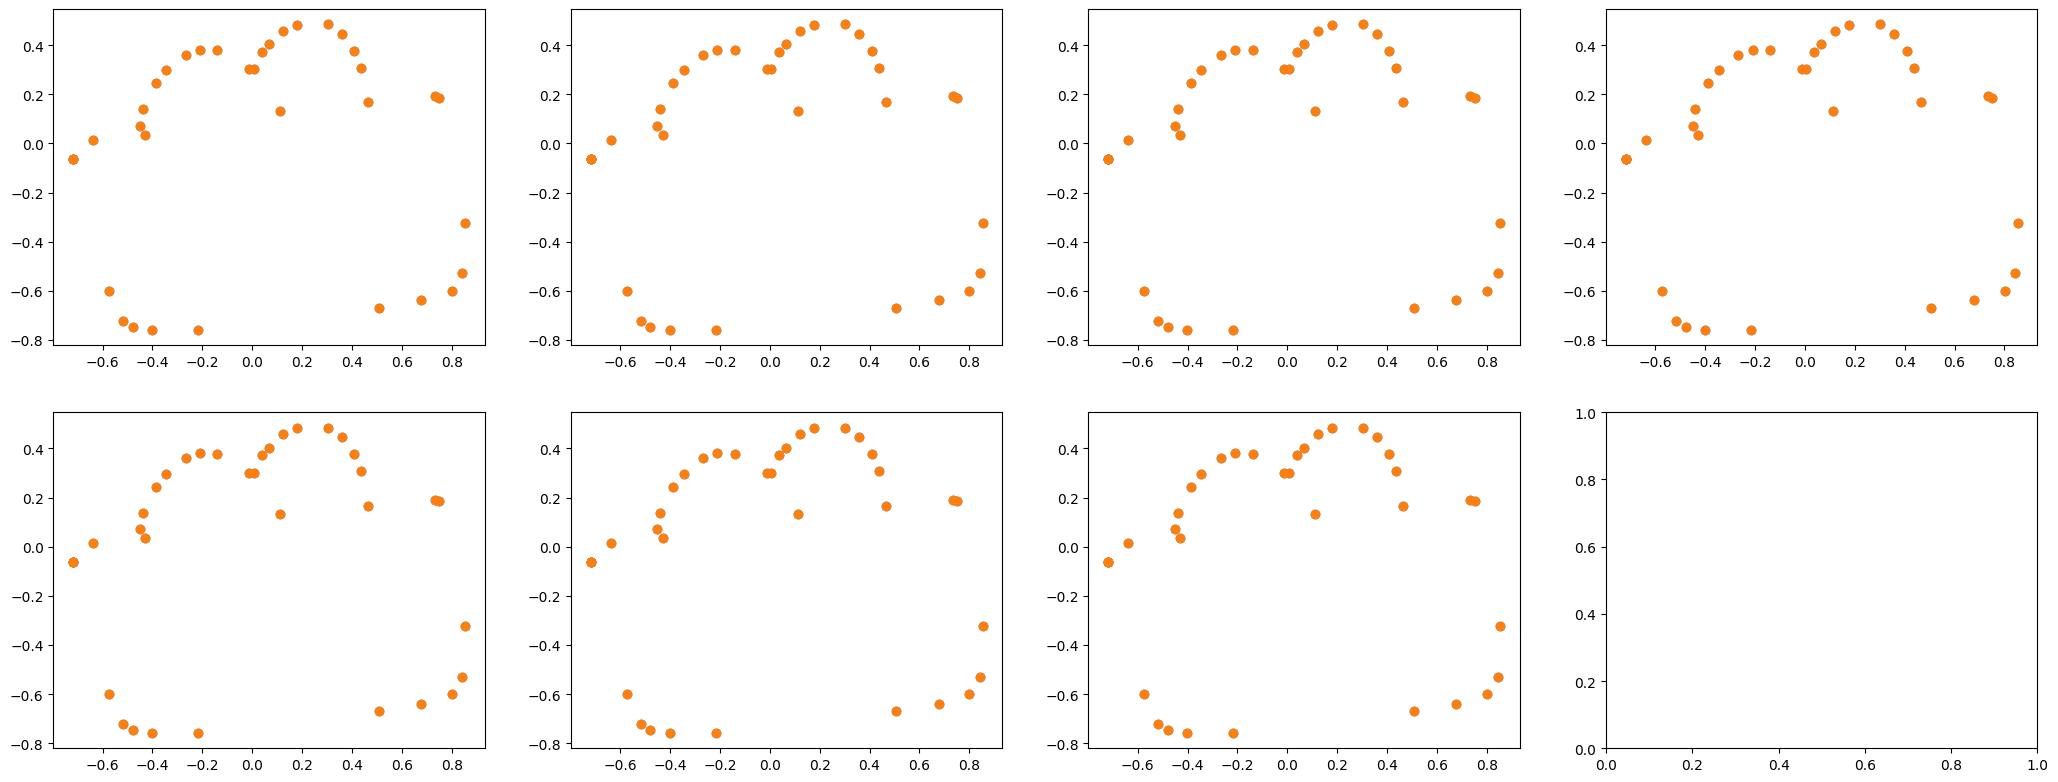

In [12]:
fig, axis = plt.subplots(2, 4, figsize=(6.4 * 4, 2 * 4.8))
axis = axis.flatten()
for i in range(len(data)):
    #draw_sketch(data[i]['pos_absolute'], data[i]['stroke_id'], axis[i])
    axis[i].scatter(data[i][0]['pos_absolute'][:, 0], -data[i][0]['pos_absolute'][:, 1])
    pos_relative = normalize_absolute_coords(data[i][0]['pos_relative'].cumsum(axis=0))
    axis[i].scatter(pos_relative[:, 0], -pos_relative[:, 1])

/tmp/ipykernel_30058/2522444372.py:15: RuntimeWarning: invalid value encountered in divide
  delta = delta / np.sqrt((delta ** 2).sum(axis=1))[:, None]


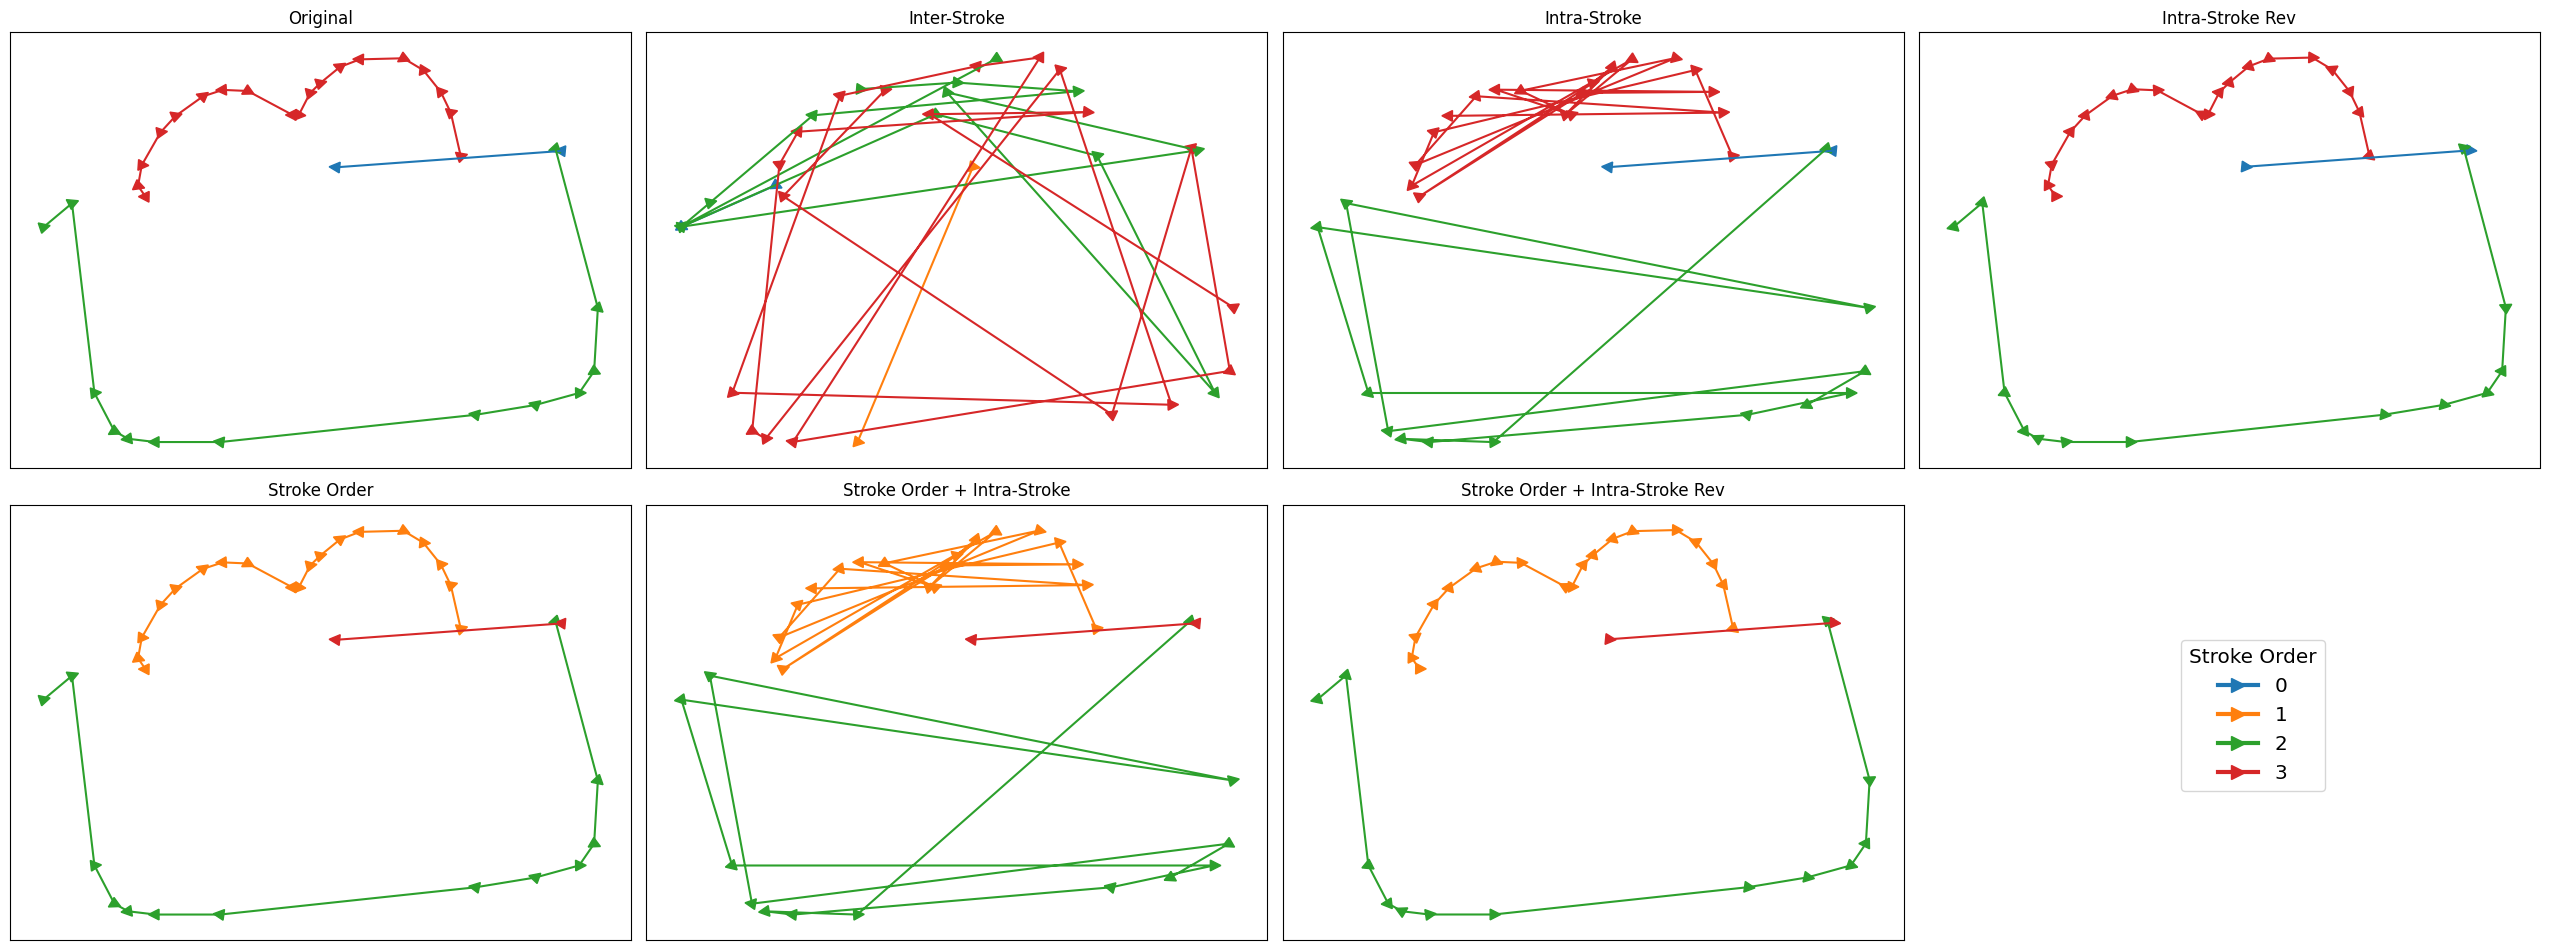

In [13]:
prop_cycle = plt.rcParams['axes.prop_cycle']
default_colors = prop_cycle.by_key()['color']
fig, axis = plt.subplots(2, 4, figsize=(6.4 * 4, 2 * 4.8))
axis = axis.flatten()
for i in range(len(data)):
    axis[i].set_title(data[i][1])
    draw_sketch(data[i][0]['pos_absolute'], data[i][0]['stroke_id'], axis[i])
    axis[i].set_xticks([])
    axis[i].set_yticks([])
axis[-1].set_axis_off()

ax = plt.gca()
for stroke in np.unique(data[0][0]['stroke_id']):
    ax.plot([], [], marker=">", markersize=10, linewidth=3, color=default_colors[stroke], label=int(stroke))
handles, labels = ax.get_legend_handles_labels()
fig.legend( handles, labels, title="Stroke Order", loc='center left', ncol=1, bbox_to_anchor=(0.85, 0.25), fontsize='x-large', title_fontsize='x-large')

plt.tight_layout()


In [15]:
data[0][0]['stroke_id']

array([0, 0, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3], dtype=int32)

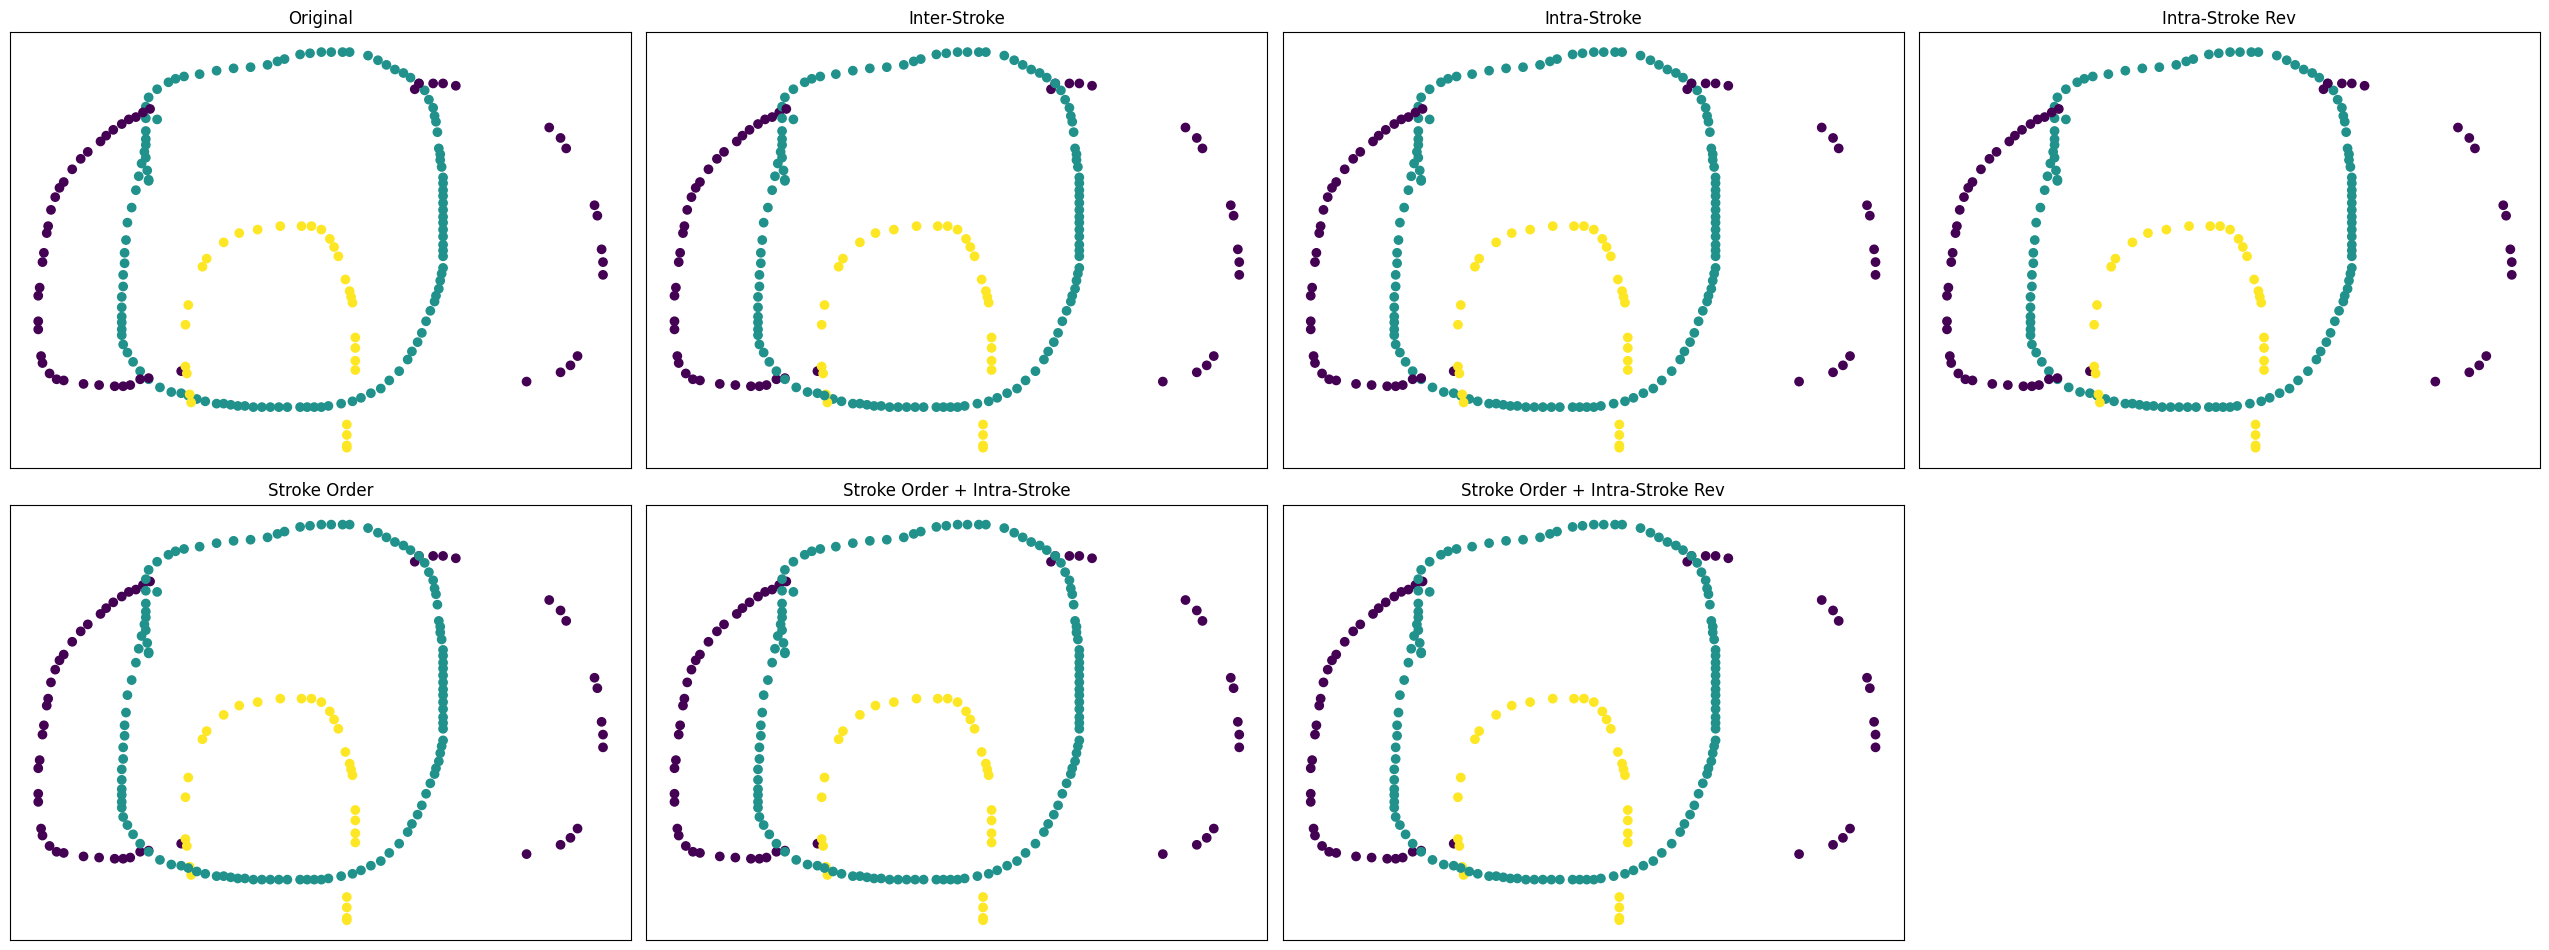

In [15]:
fig, axis = plt.subplots(2, 4, figsize=(6.4 * 4, 2 * 4.8))
axis = axis.flatten()
for i in range(len(data)):
    axis[i].set_title(data[i][1])
    axis[i].scatter(data[i][0]['pos_absolute'][:, 0], -data[i][0]['pos_absolute'][:, 1], c=data[i][0]['label'])
    axis[i].set_xticks([])
    axis[i].set_yticks([])
axis[-1].set_axis_off()

plt.tight_layout()

In [51]:
for i in range(7):
    print(data[i][1])
    stroke_id = data[i][0]['stroke_id']
    stroke_pos = data[i][0]['stroke_pos']
    pen_state = data[i][0]['pen_state']

    #print(stroke_id)
    #print(stroke_pos)
    #print(pen_state)
    
    for stroke in range(stroke_id.max()+1):
        if stroke == 0:
            print((stroke_pos[stroke == stroke_id] == np.arange(len(stroke_pos[stroke == stroke_id]))).all(), pen_state[stroke == stroke_id].sum(axis=0), pen_state[stroke == stroke_id][-1, :], pen_state[stroke == stroke_id][0, :])
        else:
            print((stroke_pos[stroke == stroke_id] == np.arange(len(stroke_pos[stroke == stroke_id]))).all(), pen_state[stroke == stroke_id].sum(axis=0), pen_state[stroke == stroke_id][-1, :])


Original
True [1. 1. 0.] [0. 1. 0.] [1. 0. 0.]
True [1. 1. 0.] [0. 1. 0.]
True [12.  1.  0.] [0. 1. 0.]
True [18.  0.  1.] [0. 0. 1.]
Inter-Stroke
True [1. 1. 0.] [0. 1. 0.] [1. 0. 0.]
True [1. 1. 0.] [0. 1. 0.]
True [12.  1.  0.] [0. 1. 0.]
True [18.  0.  1.] [0. 0. 1.]
Intra-Stroke
True [1. 1. 0.] [0. 1. 0.] [1. 0. 0.]
True [1. 1. 0.] [0. 1. 0.]
True [12.  1.  0.] [0. 1. 0.]
True [18.  0.  1.] [0. 0. 1.]
Intra-Stroke Rev
True [1. 1. 0.] [0. 1. 0.] [1. 0. 0.]
True [1. 1. 0.] [0. 1. 0.]
True [12.  1.  0.] [0. 1. 0.]
True [18.  0.  1.] [0. 0. 1.]
Stroke Order
True [1. 1. 0.] [0. 1. 0.] [1. 0. 0.]
True [18.  1.  0.] [0. 1. 0.]
True [12.  1.  0.] [0. 1. 0.]
True [1. 0. 1.] [0. 0. 1.]
Stroke Order + Intra-Stroke
True [1. 1. 0.] [0. 1. 0.] [1. 0. 0.]
True [18.  1.  0.] [0. 1. 0.]
True [12.  1.  0.] [0. 1. 0.]
True [1. 0. 1.] [0. 0. 1.]
Stroke Order + Intra-Stroke Rev
True [1. 1. 0.] [0. 1. 0.] [1. 0. 0.]
True [18.  1.  0.] [0. 1. 0.]
True [12.  1.  0.] [0. 1. 0.]
True [1. 0. 1.] [0. 0. 1.]


In [107]:
data1 = QuickDrawDataset("../data/quickdraw", split='train', perturbations=PerturbationsConfig(inter_stroke=False))[100]
data2 = QuickDrawDataset("../data/quickdraw", split='train', perturbations=PerturbationsConfig(inter_stroke=True))[100]

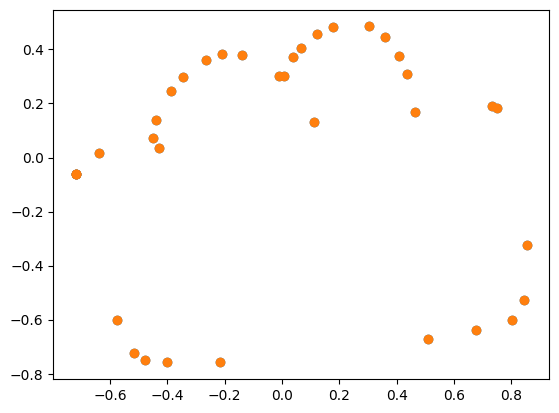

In [110]:
plt.scatter(data1['pos_absolute'][:, 0], -data1['pos_absolute'][:, 1])
plt.scatter(data2['pos_absolute'][:, 0], -data2['pos_absolute'][:, 1])

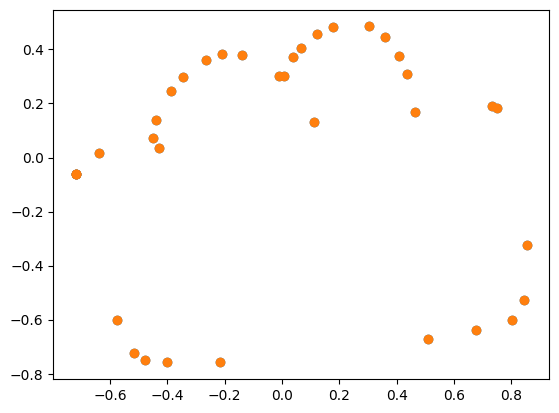

In [111]:
plt.scatter(data1['pos_absolute'][:, 0], -data1['pos_absolute'][:, 1])
pos = normalize_absolute_coords(data2['pos_relative'].cumsum(axis=0))
plt.scatter(pos[:, 0], -pos[:, 1])

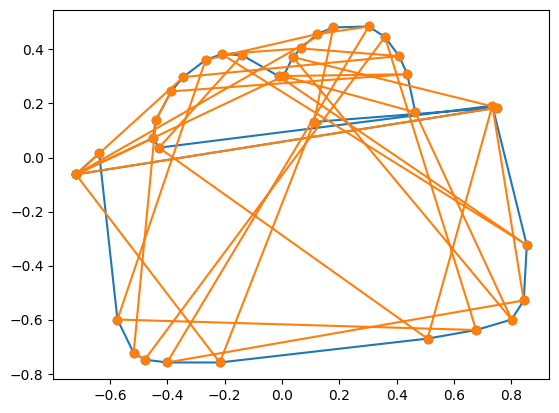

In [123]:
plt.plot(data1['pos_absolute'][:, 0], -data1['pos_absolute'][:, 1], marker='o')
plt.plot(data2['pos_absolute'][:, 0], -data2['pos_absolute'][:, 1], marker='o')

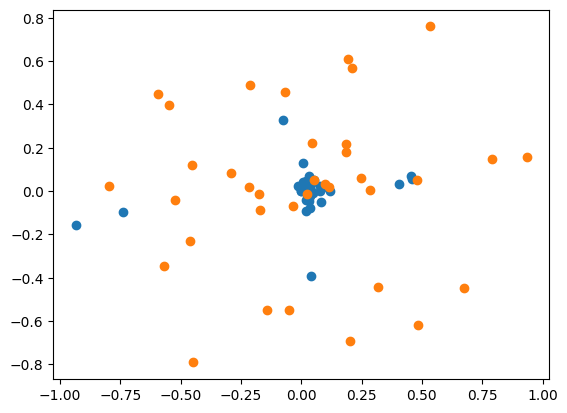

In [127]:
plt.scatter(data1['pos_relative'][:, 0], -data1['pos_relative'][:, 1])
plt.scatter(data2['pos_relative'][:, 0], -data2['pos_relative'][:, 1])